In [1]:
!unzip Multilevel-Convolutional-Neural-Networks-for-parametric-obstacle-problems-main.zip
%cd Multilevel-Convolutional-Neural-Networks-for-parametric-obstacle-problems-main

# HÜCRE #1 — fem-on-colab installer (doğru script adı)
!wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh" || wget "https://fem-on-colab.github.io/releases/fenicsx-install-release-real.sh" -O "/tmp/fenics-install.sh"
!bash /tmp/fenics-install.sh

# FEniCS hazır mı kontrol et, yoksa kur
try:
    import dolfin
    from petsc4py import PETSc
    print("FEniCS ready:", dolfin.__version__)
except:
    !wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh"
    !bash /tmp/fenics-install.sh
    import dolfin
    from petsc4py import PETSc
    print("FEniCS installed:", dolfin.__version__)


import sys, os, importlib.util

root = "/content/Multilevel-Convolutional-Neural-Networks-for-parametric-obstacle-problems-main"
code_dir = os.path.join(root, "code")
init_path = os.path.join(code_dir, "__init__.py")

if 'code' in sys.modules:
    del sys.modules['code']

spec = importlib.util.spec_from_file_location("code", init_path)
code_pkg = importlib.util.module_from_spec(spec)
code_pkg.__path__ = [code_dir]
sys.modules['code'] = code_pkg
spec.loader.exec_module(code_pkg)


Archive:  Multilevel-Convolutional-Neural-Networks-for-parametric-obstacle-problems-main.zip
e6cbc944c55f06cfdc8056845239120b9bb52712
   creating: Multilevel-Convolutional-Neural-Networks-for-parametric-obstacle-problems-main/
  inflating: Multilevel-Convolutional-Neural-Networks-for-parametric-obstacle-problems-main/.gitignore  
  inflating: Multilevel-Convolutional-Neural-Networks-for-parametric-obstacle-problems-main/README.md  
   creating: Multilevel-Convolutional-Neural-Networks-for-parametric-obstacle-problems-main/code/
   creating: Multilevel-Convolutional-Neural-Networks-for-parametric-obstacle-problems-main/code/FinalConvModel/
  inflating: Multilevel-Convolutional-Neural-Networks-for-parametric-obstacle-problems-main/code/FinalConvModel/BuildDataSets.py  
  inflating: Multilevel-Convolutional-Neural-Networks-for-parametric-obstacle-problems-main/code/FinalConvModel/BuildDataSetsResidual.py  
   creating: Multilevel-Convolutional-Neural-Networks-for-parametric-obstacle-probl

In [2]:
 import pathlib

replacements = {
    "np.int64": "np.int64",   # bırak
    "np.int32": "np.int32",   # bırak
    "np.int)": "int)",
}
# genel düzeltme (np.int, np.float, np.bool -> builtin tipleri)
for p in pathlib.Path("code").rglob("*.py"):
    txt = p.read_text()
    new = txt.replace("np.int)", "int)").replace("np.int,", "int,")
    new = new.replace("np.int ", "int ").replace("np.int\n", "int\n")
    new = new.replace("np.float)", "float)").replace("np.float,", "float,")
    new = new.replace("np.float ", "float ").replace("np.float\n", "float\n")
    new = new.replace("np.bool)", "bool)").replace("np.bool,", "bool,")
    new = new.replace("np.bool ", "bool ").replace("np.bool\n", "bool\n")
    # eski alias'ların pek çok varyantı olabileceğinden ekstra basit değişiklik
    if new != txt:
        p.write_text(new)
        print("patched:", p)
print("patching done")


patched: code/ParamPDE/field/rough.py
patching done


# Restart!

In [1]:
import sys, os, importlib.util

root = "/content/Multilevel-Convolutional-Neural-Networks-for-parametric-obstacle-problems-main"
code_dir = os.path.join(root, "code")
init_path = os.path.join(code_dir, "__init__.py")

if 'code' in sys.modules:
    del sys.modules['code']

spec = importlib.util.spec_from_file_location("code", init_path)
code_pkg = importlib.util.module_from_spec(spec)
code_pkg.__path__ = [code_dir]
sys.modules['code'] = code_pkg
spec.loader.exec_module(code_pkg)
print("code package reloaded after restart")



code package reloaded after restart


In [2]:
%cd Multilevel-Convolutional-Neural-Networks-for-parametric-obstacle-problems-main


/content/Multilevel-Convolutional-Neural-Networks-for-parametric-obstacle-problems-main


In [ ]:
from code.FinalConvModel.BuildDataSets import build_data_set

build_data_set(
    problem='obstacle-rough',
    param_dimension=100,      # p = 10
    num_corrections=7,       # L = 7 seviye
    num_samples=1000,       # train
    num_val_samples=0,    # validation
    num_test_samples=0,   # test
    obstacle_parameter=False,  # obstacle sabit (deterministic)
    fixed_radii=False,         # bu case için kullanılmıyor
    saving_path='./code/FinalConvModel/Data/deterministic_p10'
)



Problem: obstacle-rough
problem:  obstacle-rough
almost starting
[2026-03-18 11:19:16] Loading problem: obstacle-rough


/content/Multilevel-Convolutional-Neural-Networks-for-parametric-obstacle-problems-main/code/ParamPDE/field/testfield.py:9: SyntaxWarning: invalid escape sequence '\s'
  a(x,y) = mean + scale * \sum_{m=1}^M (m+1)^decay y_m \sin(\pi b_1 x_1) \sin(\pi b_2 x_2)
/content/Multilevel-Convolutional-Neural-Networks-for-parametric-obstacle-problems-main/code/ParamPDE/field/rough.py:10: SyntaxWarning: invalid escape sequence '\s'
  a(x,y) = mean + scale * \sum_{m=1}^M (m+1)^decay y_m \sin(\pi b_1 x_1) \sin(\pi b_2 x_2)


Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling element ffc_element_3801828c0f66b7190a7fd5819465b3d5b34b9149

INFO:FFC:Compiler stage 1: Analyzing element(s)
INFO:FFC:--------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00195003 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 1 elements
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 1 dofmaps
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 0 coordinate mappings
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 0.235329 seconds.

INFO:FFC:Compiler stage 3: Optimizing intermediate representation
INFO:FFC:----------------------------

Maximal number of random coefficients: 220
Maximal norm: 25.906236686830383
[2026-03-18 11:20:10] Loading sampler: random-uniform (dimension: 100)
in sampler
starting training samples
get y imgs
solve
0
H -0.9185138305123988
Calling FFC just-in-time (JIT) compiler, this may take some time.


...

Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling coordinate_mapping ffc_coordinate_mapping_84d495a78101e005b3c3473583b2e920e2771158

INFO:FFC:Compiler stage 1: Analyzing coordinate_mapping(s)
INFO:FFC:-------------------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00235629 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 0 elements
INFO:FFC:  Computing representation of 0 dofmaps
INFO:FFC:  Computing representation of 1 coordinate mappings
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 0.0107293 seconds.

INFO:FFC:Compiler stage 3: Optimizing intermediate representation
INFO:FFC:--------------------------------------------------------
INFO

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_193962280c1c8db8e20c44b9fba29e9ef4a5bd5d

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      2
  Arguments:                 '(v_0, v_1)'
  Number of coefficients:    1
  Coefficients:              '[f_304742]'
  Unique elements:           'CG1(?,?), R0(?,?), Vector<2 x CG1(?,?)>'
  Unique sub elements:       'CG1(?,?), R0(?,?), Vector<2 x CG1(?,?)>'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 0
INFO:FFC:  quadrature_degree: 0
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.0243294 seconds.

INFO:FFC:Compiler

1
H 0.29722435647104306
2
H -0.19586487289701138
3
H 0.9232772147652211
4
H -0.7249251303216646
5
H 0.4924189112953741
6
H -0.21278404359993242
7
H -0.5469996167387312
8
H 0.4943714633304488
9
H -0.7864946535071524
10
H 0.7072386577641654
11
H 0.9803179849072583
12
H -0.20121984976934248
13
H -0.4709969414455426
14
H 0.7216790337234262
15
H -0.5203943941121849
16
H -0.028777006533213356
17
H -0.3337746026840971
18
H 0.7284767714069234
19
H 0.5005979802877796
20
H -0.8177440764833257
21
H 0.08235023156498222
22
H -0.711244564436426
23
H 0.8154870797726566
24
H -0.8020384159746818
25
H -0.7118885691018599
26
H -0.26036962698719157
27
H -0.25726756413513896
28
H 0.8701937660979278
29
H 0.8852347838492161
30
H -0.4380630875284208
31
H -0.46729539871506054
32
H -0.4778142933278877
33
H -0.4049709957332277
34
H 0.3663259232939393
35
H 0.7623441039623411
36
H 0.04651615969949807
37
H -0.5206946935474808
38
H 0.5780932819658948
39
H 0.2379465349900085
40
H -0.5178994376698192
41
H 0.8249457215

<Figure size 640x480 with 0 Axes>

In [ ]:
!zip -r /content/dataset.zip code/FinalConvModel/Data/deterministic_p10


  adding: code/FinalConvModel/Data/deterministic_p10/ (stored 0%)
  adding: code/FinalConvModel/Data/deterministic_p10/train_ys.npy (deflated 5%)
  adding: code/FinalConvModel/Data/deterministic_p10/val_ys.npy (deflated 44%)
  adding: code/FinalConvModel/Data/deterministic_p10/test_u_imgs.npy (deflated 47%)
  adding: code/FinalConvModel/Data/deterministic_p10/data_sampler.p (deflated 65%)
  adding: code/FinalConvModel/Data/deterministic_p10/test_ys.npy (deflated 44%)
  adding: code/FinalConvModel/Data/deterministic_p10/train_ys_imgs.npy (deflated 16%)
  adding: code/FinalConvModel/Data/deterministic_p10/train_u_imgs.npy (deflated 11%)
  adding: code/FinalConvModel/Data/deterministic_p10/test_u_imgs_fine.npy (deflated 47%)
  adding: code/FinalConvModel/Data/deterministic_p10/val_u_imgs.npy (deflated 47%)
  adding: code/FinalConvModel/Data/deterministic_p10/test_ys_imgs.npy (deflated 42%)
  adding: code/FinalConvModel/Data/deterministic_p10/val_ys_imgs.npy (deflated 42%)


In [3]:
# gerekli importlar
import os
import numpy as np
import torch
from code.FinalConvModel.DataHandler import MultiLevelRefinementSampler
from code.FinalConvModel.TrainModel import get_transforms_and_orderings

# problemInfo yolunu kendi proje dizinine göre ayarla.
# build_data_set ile ürettiğin verilerin bulunduğu klasöre işaret et.
# örnek: "./code/FinalConvModel/Data/deterministic_p10" veya orijinal paramPDE dizinin
problem_info = "./code/ParamPDE/samples-obstacle"  # gerektiğinde değiştir

# DataSampler oluştur (overwrite_levels'ı dataset'in fine seviyesi kadar ver)
# overwrite_levels burada yüksek bir değer; en son çözünürlüğü kapsayacak şekilde vermelisin.
DataSampler = MultiLevelRefinementSampler(problemInfo=problem_info, overwrite_levels=9)

# get_transforms_and_orderings ile img_sizes bilgisini al
num_corrections = 9
device = torch.device("cpu")
upsampling_matrices, upsampling_img_to_vec, upsampling_vec_to_img, img_sizes = \
    get_transforms_and_orderings(DataSampler, num_corrections, device)

# img_sizes kontrol (opsiyonel, çıktı görmek istersen)
for i, s in enumerate(img_sizes):
    print(i, s)

# interpolate_to_higher_level fonksiyonunu tanımla
def interpolate_to_higher_level(u_imgs, level0, level1):
    imgs_interp = []
    # u_imgs numpy array ya da torch tensor olabilir; burada numpy olarak bekliyoruz
    if isinstance(u_imgs, torch.Tensor):
        u_imgs = u_imgs.detach().cpu().numpy()
    u_imgs = np.asarray(u_imgs)
    # tek görüntü gelirse (H, W) -> (1, H, W)
    if u_imgs.ndim == 2:
        u_imgs = u_imgs[None, ...]
    if u_imgs.ndim == 3 and u_imgs.shape[1] != img_sizes[level0][0]:
        # bazı kodlarda kanal eksikliği olabilir, eğer (N, H, W) değilse try düzelt
        if u_imgs.shape[-2:] == img_sizes[level0]:
            pass
    for u_img in u_imgs:
        # u_img beklenen formatta (H, W)
        u_func = DataSampler.image_to_function(u_img.squeeze(), level0)
        new_u_func = DataSampler.get_higher_interpolation(u_func, level1)
        imgs_interp.append(np.array(DataSampler.function_to_image(new_u_func, level1)))
    return np.stack(imgs_interp, axis=0)


[2026-03-18 22:55:02] Loading problem: obstacle


/content/Multilevel-Convolutional-Neural-Networks-for-parametric-obstacle-problems-main/code/ParamPDE/field/testfield.py:9: SyntaxWarning: invalid escape sequence '\s'
  a(x,y) = mean + scale * \sum_{m=1}^M (m+1)^decay y_m \sin(\pi b_1 x_1) \sin(\pi b_2 x_2)


Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling element ffc_element_3801828c0f66b7190a7fd5819465b3d5b34b9149

INFO:FFC:Compiler stage 1: Analyzing element(s)
INFO:FFC:--------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00281239 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 1 elements
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 1 dofmaps
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 0 coordinate mappings
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 0.167094 seconds.

INFO:FFC:Compiler stage 3: Optimizing intermediate representation
INFO:FFC:----------------------------

[2026-03-18 22:55:30] Loading sampler: random-uniform (dimension: 10)
in sampler
0 (11, 11)
1 (21, 21)
2 (41, 41)
3 (81, 81)
4 (161, 161)
5 (321, 321)
6 (641, 641)
7 (1281, 1281)


In [4]:
DataSampler.is_obstacle_parameter

False

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving test_results_321.npz to test_results_321.npz


In [7]:
import numpy as np

data = np.load("det-100p-test results.npz")
print("Keys:", data.files)

preds = data["prediction"]
print(preds.shape)

Keys: ['prediction', 'target']
(100, 321, 321)


In [8]:
level0 = 6
level1 = 8

imgs_1281 = interpolate_to_higher_level(
    u_imgs=preds,
    level0=level0,
    level1=level1
)

print(imgs_1281.shape)

(100, 1281, 1281)


In [10]:
import numpy as np

gt = np.load("/content/test_u_imgs_fine.npy")

print("GT shape:", gt.shape)
print("Pred shape:", imgs_1281.shape)

GT shape: (100, 1281, 1281)
Pred shape: (100, 1281, 1281)


In [11]:
import numpy as np
from google.colab import files

def compute_all_errors(u_pred, u_true):
    N = u_pred.shape[-1]
    h = 1.0 / (N - 1)

    def grad(u):
        ux = (u[:, 2:, 1:-1] - u[:, :-2, 1:-1]) / (2*h)
        uy = (u[:, 1:-1, 2:] - u[:, 1:-1, :-2]) / (2*h)
        return ux, uy

    diff = u_pred - u_true

    # L2
    l2_abs = np.sqrt(np.sum(diff**2, axis=(1,2)) * h**2)
    l2_true = np.sqrt(np.sum(u_true**2, axis=(1,2)) * h**2)
    l2_rel = l2_abs / l2_true

    # H1
    dx_d, dy_d = grad(diff)
    dx_t, dy_t = grad(u_true)

    h1_abs = np.sqrt(
        np.sum(diff**2, axis=(1,2)) * h**2 +
        np.sum(dx_d**2 + dy_d**2, axis=(1,2)) * h**2
    )

    h1_true = np.sqrt(
        np.sum(u_true**2, axis=(1,2)) * h**2 +
        np.sum(dx_t**2 + dy_t**2, axis=(1,2)) * h**2
    )

    h1_rel = h1_abs / h1_true

    return l2_abs, l2_rel, h1_abs, h1_rel


# error hesapla
l2_abs, l2_rel, h1_abs, h1_rel = compute_all_errors(imgs_1281, gt)

# dosya adı — sondaki sayıyı her testte değiştir
filename = "results_10-obstacle_1.npy"

# hepsini tek dosyada sakla
results_dict = {
    "l2_abs": l2_abs,
    "l2_rel": l2_rel,
    "h1_abs": h1_abs,
    "h1_rel": h1_rel
}

np.save(filename, results_dict)

# indir
files.download(filename)

print("Kaydedildi ve indirildi:", filename)
print(f"Batch Mean Relative L2  = {np.mean(l2_rel)*100:.5f} %")
print(f"Batch Mean Relative H1  = {np.mean(h1_rel)*100:.5f} %")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Kaydedildi ve indirildi: results_10-obstacle_1.npy
Batch Mean Relative L2  = 0.01280 %
Batch Mean Relative H1  = 0.43863 %


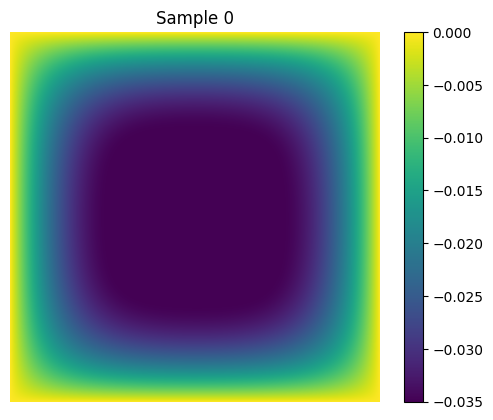

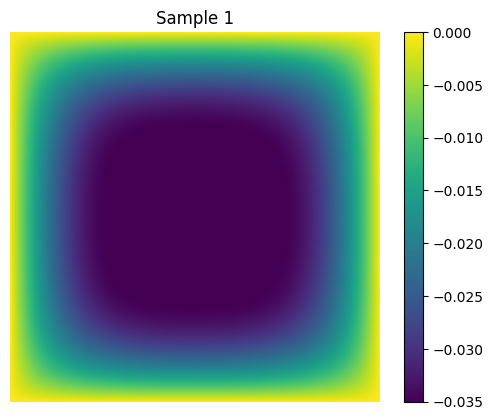

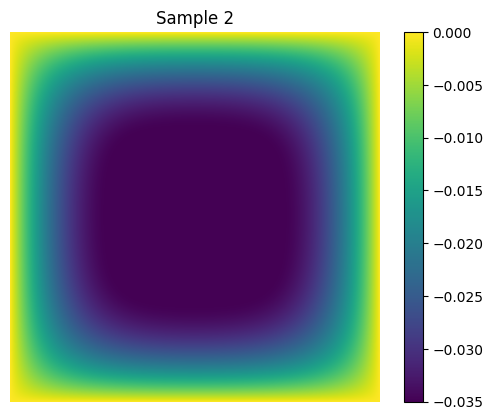

[[-1.58070179e-08  1.06865627e-10  1.60207492e-08 ...  9.64491846e-08
   4.82245923e-08  5.35400527e-24]
 [ 4.03674676e-08 -7.96405220e-06 -7.94813832e-06 ...  9.64491846e-08
   4.82245923e-08 -4.01550396e-24]
 [ 9.65419531e-08 -7.90787772e-06 -1.59122974e-05 ...  9.64491846e-08
   4.82245923e-08  8.03100791e-24]
 ...
 [ 1.13697297e-06  1.13697297e-06  1.13697297e-06 ... -1.53999408e-05
  -7.69997041e-06 -1.28230267e-21]
 [ 5.68486485e-07  5.68486485e-07  5.68486485e-07 ... -7.69997041e-06
  -7.69997041e-06 -1.70973689e-21]
 [ 6.31146784e-23 -4.73360088e-23  9.46720177e-23 ... -1.28230267e-21
  -1.70973689e-21 -1.70973689e-21]]


In [ ]:
import matplotlib.pyplot as plt

# ilk 3 örneği seç
samples = imgs_1281[:3]

for i in range(3):
    plt.figure()
    plt.imshow(samples[i], cmap="viridis")
    plt.colorbar()
    plt.title(f"Sample {i}")
    plt.axis("off")
    plt.show()
print(imgs_1281[3])

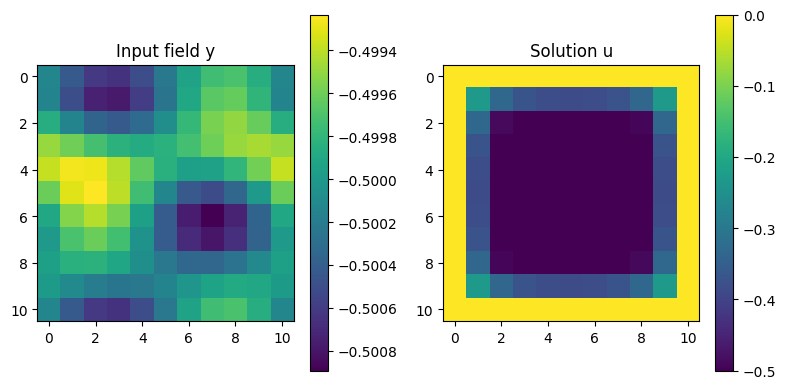

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

y = np.load('code/FinalConvModel/Data/obstacle100rough/train_ys_imgs.npy')
u = np.load('code/FinalConvModel/Data/obstacle100rough/train_u_imgs.npy')

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Input field y")
plt.imshow(y[0])
plt.colorbar()

plt.subplot(1,2,2)
plt.title("Solution u")
plt.imshow(u[0])
plt.colorbar()

plt.tight_layout()
plt.show()
